<a href="https://colab.research.google.com/github/Nikhitha-Vineeth/GIT-NIK/blob/master/imgdisparitystereo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

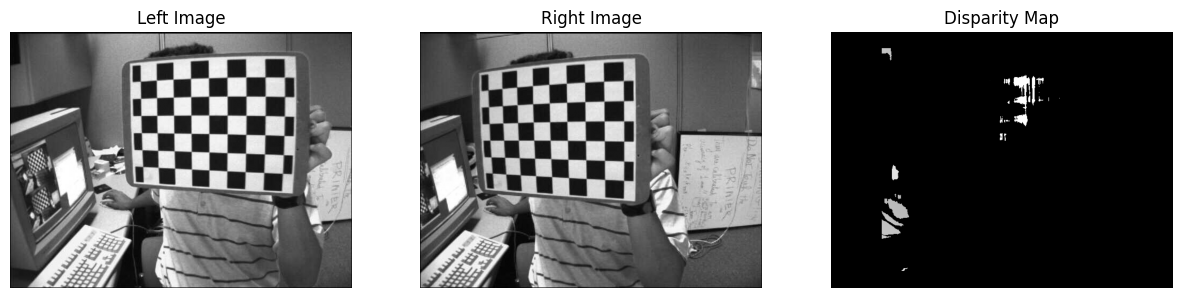

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Download stereo images
urlL = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left01.jpg"
urlR = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/right01.jpg"

urllib.request.urlretrieve(urlL, "left.jpg")
urllib.request.urlretrieve(urlR, "right.jpg")

# Read images
imgL = cv2.imread('left.jpg', 0)
imgR = cv2.imread('right.jpg', 0)

# Create StereoBM object
stereo = cv2.StereoBM_create(numDisparities=64, blockSize=65)

# Compute disparity
disparity = stereo.compute(imgL, imgR)

# Normalize for visualization
disparity = cv2.normalize(disparity, None, alpha=0, beta=255,
                          norm_type=cv2.NORM_MINMAX)
disparity = np.uint8(disparity)

# Display
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(imgL, cmap='gray')
plt.title("Left Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(imgR, cmap='gray')
plt.title("Right Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(disparity, cmap='gray')
plt.title("Disparity Map")
plt.axis("off")

plt.show()


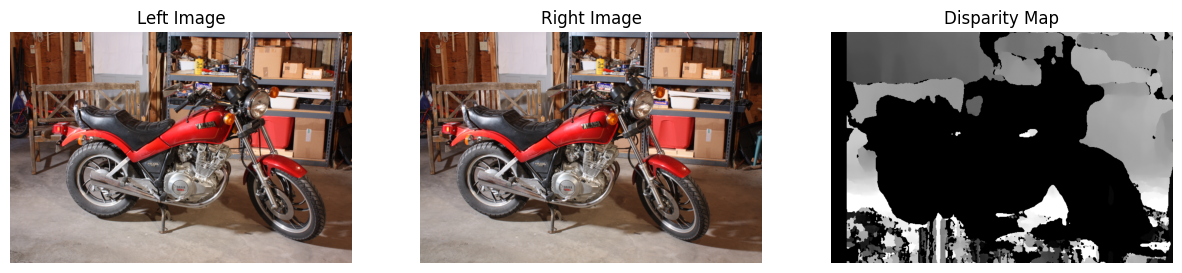

In [13]:
from skimage import data
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load stereo pair from skimage
stereo_data = data.stereo_motorcycle()

imgL = stereo_data[0]
imgR = stereo_data[1]

# Convert to grayscale
imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

# Create StereoSGBM (better than StereoBM)
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=34,
    blockSize=30
)

disparity = stereo.compute(imgL_gray, imgR_gray)

# Normalize for display
disparity = cv2.normalize(disparity, None, 0, 255,
                          cv2.NORM_MINMAX)
disparity = np.uint8(disparity)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(imgL)
plt.title("Left Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(imgR)
plt.title("Right Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(disparity, cmap='gray')
plt.title("Disparity Map")
plt.axis("off")

plt.show()


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(2,activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,986 (14.14 MB)

 Trainable params: 3,705,986 (14.14 MB)

 Non-trainable params: 0 (0.00 B)